# Gate Synthesis — syntesis_1_2\n\nTest dei gate definiti in `syntesis_1_2.py` usando Bloqade/squin.

In [1]:
import sys, os, importlib
sys.path.insert(0, os.path.dirname(os.path.abspath("syntesis_1_2.py")))

import gate_syntesis
importlib.reload(gate_syntesis)

import numpy as np
from qiskit.synthesis import gridsynth_rz
import gate_syntesis
importlib.reload(gate_syntesis)
from gate_syntesis import *
from bloqade import squin, tsim
from bloqade.types import Qubit
from kirin.dialects.ilist import IList
from typing import Any

Register = IList[Qubit, Any]

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

## Test gate a 1 qubit: X, Y, Z

In [2]:
@squin.kernel
def test_single_qubit_gates():
    qubits = squin.qalloc(1)
    X_gate(qubits[0])
    Y_gate(qubits[0])
    Z_gate(qubits[0])

tsim.Circuit(test_single_qubit_gates).diagram()

## Test gate a 2 qubit: CZ, SWAP

In [3]:
@squin.kernel
def test_two_qubit_gates():
    qubits = squin.qalloc(2)
    CZ_gate(qubits[0], qubits[1])
    SWAP_gate(qubits[0], qubits[1])

tsim.Circuit(test_two_qubit_gates).diagram()

## Test Toffoli (CCX) — gate a 3 qubit

In [4]:
@squin.kernel
def test_toffoli():
    qubits = squin.qalloc(3)
    Toffoli_gate(qubits[0], qubits[1], qubits[2])

tsim.Circuit(test_toffoli).diagram()

In [5]:
rz3 = Rz_gate(3)  # crea il kernel fuori da squin

@squin.kernel
def test_rz():
    qubits = squin.qalloc(1)
    rz3(qubits[0])

tsim.Circuit(test_rz).diagram(width=1200)

In [6]:
N_VALUES = range(8)
PART2_EPSILON = 1e-4

part2_circuits = {}
part2_sequences = {}

for n in N_VALUES:
    theta = np.pi / (2 ** n)
    circ = gridsynth_rz(theta, epsilon=PART2_EPSILON)
    sequence = gate_sequence_from_circuit(circ)

    part2_circuits[n] = circ
    part2_sequences[n] = sequence

    t_count = t_count_from_sequence(sequence)
    clifford_count = len(sequence) - t_count
    print(f"n={n}: T-count={t_count}, Clifford-count={clifford_count}")

n=0: T-count=0, Clifford-count=2
n=1: T-count=0, Clifford-count=1
n=2: T-count=1, Clifford-count=0
n=3: T-count=45, Clifford-count=67
n=4: T-count=43, Clifford-count=65
n=5: T-count=36, Clifford-count=54
n=6: T-count=41, Clifford-count=65
n=7: T-count=41, Clifford-count=62


,n,logical_T_count,postselection_success_probability_exact,dropout_probability_exact
0,0,0,1.000000e+00,0.0
1,1,0,1.000000e+00,0.0
2,2,1,5.000000e-01,0.5
3,3,45,2.842171e-14,1.0
4,4,43,1.136868e-13,1.0
5,5,36,1.455192e-11,1.0
6,6,41,4.547474e-13,1.0
7,7,41,4.547474e-13,1.0


,n,logical_T_count,shots,dropout_rate_estimated
0,0,0,0,0.000
1,1,0,0,0.000
2,2,1,200,0.575


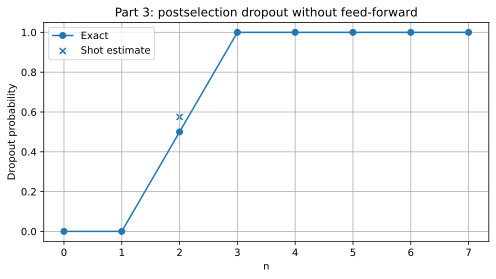

In [7]:
# ============================================================
# Part 3 — Postselection dropout without feed-forward correction
# ============================================================

import os, sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bloqade.pyqrack import StackMemorySimulator

sys.path.insert(0, os.path.dirname(os.path.abspath("syntesis_1_2.py")))

import gate_syntesis; importlib.reload(gate_syntesis)
from gate_syntesis import make_postselected_dropout_kernel, t_count_from_sequence

N_VALUES      = globals().get("N_VALUES",      range(51))
PART2_EPSILON = globals().get("PART2_EPSILON", 1e-10)
RESULTS_DIR   = globals().get("RESULTS_DIR",   "results")

if "part2_circuits" not in globals() or "part2_sequences" not in globals():
    import syntesis_part3; importlib.reload(syntesis_part3)
    part2_circuits, part2_sequences = syntesis_part3.ensure_part2_results(N_VALUES, PART2_EPSILON)

# --- Exact dropout probabilities ---
rows = []
for n in N_VALUES:
    t = t_count_from_sequence(part2_sequences[n])
    rows.append({"n": n, "logical_T_count": t,
                 "postselection_success_probability_exact": 2**-t,
                 "dropout_probability_exact": 1 - 2**-t})
df_exact = pd.DataFrame(rows)
display(df_exact)

# --- Shot-based estimates (only for small T-count) ---
DROPOUT_SIM_SHOTS     = 200
MAX_SIMULATED_T_COUNT = 2

sim_rows = []
for n in N_VALUES:
    t = t_count_from_sequence(part2_sequences[n])
    if t > MAX_SIMULATED_T_COUNT:
        continue
    if t == 0:
        sim_rows.append({"n": n, "logical_T_count": t, "shots": 0, "dropout_rate_estimated": 0.0})
        continue
    kernel   = make_postselected_dropout_kernel(part2_sequences[n])
    task     = StackMemorySimulator(min_qubits=1 + t).task(kernel)
    dropouts = sum(int(task.run()) for _ in range(DROPOUT_SIM_SHOTS))
    sim_rows.append({"n": n, "logical_T_count": t,
                     "shots": DROPOUT_SIM_SHOTS, "dropout_rate_estimated": dropouts / DROPOUT_SIM_SHOTS})
df_sim = pd.DataFrame(sim_rows)
display(df_sim)

# --- Plot ---
os.makedirs(RESULTS_DIR, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_exact["n"], df_exact["dropout_probability_exact"], marker="o", label="Exact")
if not df_sim.empty:
    est = df_sim[df_sim["shots"] > 0]
    ax.scatter(est["n"], est["dropout_rate_estimated"], marker="x", label="Shot estimate")
ax.set(xlabel="n", ylabel="Dropout probability",
       title="Part 3: postselection dropout without feed-forward",
       ylim=(-0.05, 1.05))
ax.set_xticks(df_exact["n"])
ax.legend(); ax.grid(True)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "part3_postselection_dropout_probability.png"), dpi=300, bbox_inches="tight")
plt.show()